<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
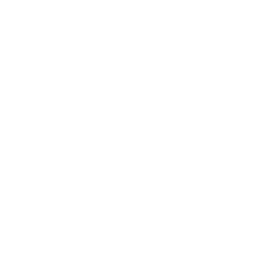
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Efficacité de la visite médicale des délégués commerciaux avec sélection des décalages</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Analytique pharmaceutique / commerciale &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé analytique

Évaluer l'impact des visites médicales auprès des médecins et de la distribution d'échantillons sur le volume mensuel de prescriptions d'un médicament de spécialité à l'aide de PROC AUTOREG. Tenir compte des schémas de prescription autocorrélés avec NLAG=3 et appliquer l'option BACKSTEP pour éliminer automatiquement les ordres de décalage non significatifs. Quantifier le rendement marginal de chaque visite médicale supplémentaire afin d'éclairer les décisions de déploiement de la force de terrain et l'alignement des territoires.

La série mensuelle synthétique est plafonnée à 100 observations dans le mode d'exécution actuel, ce qui suffit pour retrouver avec une grande précision les effets de la visite médicale, de l'échantillonnage, du formulaire et de la concurrence.

## Sources de données

| Source | Description | Enregistrements |
|--------|-------------|--------|
| WORK.DETAILING | Prescriptions mensuelles avec indicateurs de visite médicale et d'échantillons | 100 |

---

In [1]:
/* --------------------------------------------------------
   Génère des données mensuelles synthétiques de démarchage
   et d'ordonnances pour un produit pharmaceutique de spécialité
   -------------------------------------------------------- */
DONNÉES work.detailing;
    APPELER streaminit(42);
    RETENIR prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    FAIRE month_seq = 1 JUSQU_À 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* le secteur tourne sur 12 visiteurs */
        rep_id = cat('REP-', ÉCRIRE(mod(month_seq - 1, 12) + 1, z3.));
        /* visites de démarchage par mois */
        detail_visits = int(rand('normal', 8, 3));
        SI detail_visits < 0 ALORS detail_visits = 0;
        SI detail_visits > 20 ALORS detail_visits = 20;
        /* échantillons laissés aux médecins */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* statut au formulaire de l'assurance (binaire) */
        formulary_status = (rand('uniform') > 0.2);
        /* pression concurrentielle sur la part de marché */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* indice saisonnier */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* processus d'erreur AR(3) */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* modèle d'ordonnances */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        SI new_rx < 0 ALORS new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        SORTIE;
    FIN;
    SUPPRIMER prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    ÉTIQUETTE new_rx           = "Nouvelles ordonnances (NRx)"
          total_rx         = "Ordonnances totales"
          detail_visits    = "Visites de démarchage par mois"
          samples_left     = "Échantillons laissés"
          competitor_share = "Part de marché concurrente"
          obs_month        = "Mois d'observation";
    format obs_month monyy7.;
EXÉCUTER;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Statistiques descriptives de référence : ordonnances et démarchage
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.detailing n mean std MIN MAX;
    VAR new_rx total_rx detail_visits samples_left competitor_share;
EXÉCUTER;

                                                  The MEANS Procedure

 Variable          Label                                   N            Mean        Std Dev        Minimum         Maximum
 -------------------------------------------------------------------------------------------------------------------------
 new_rx            Nouvelles ordonnances (NRx)           100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Ordonnances totales                   100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Visites de démarchage par mois        100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Échantillons laissés                  100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Part de marché concurrente            100       0.2653000      0.1187090      0.0300000       0.5600000
 -------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


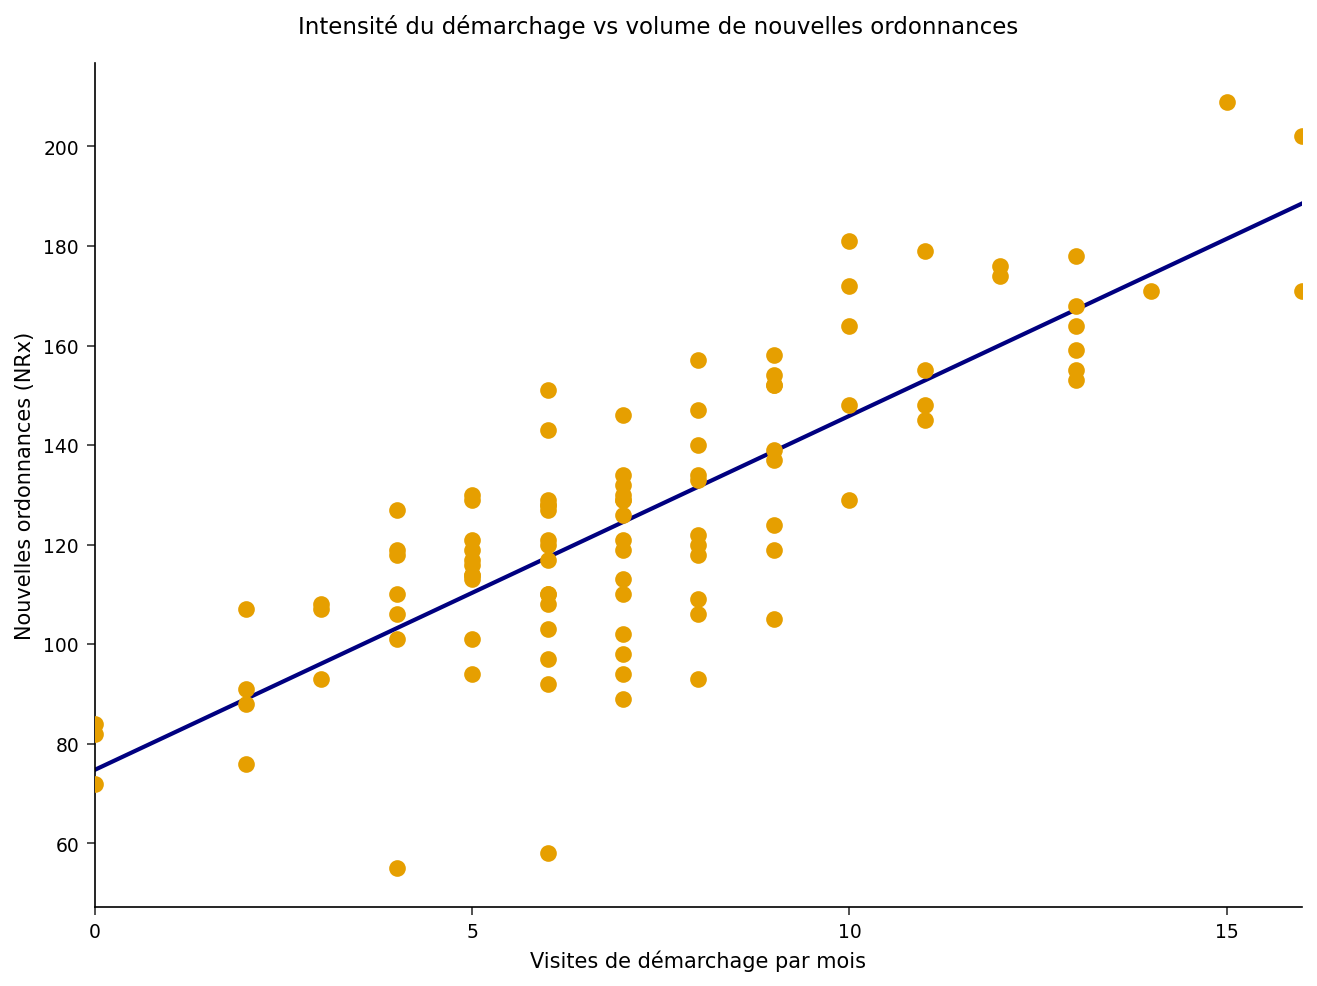

In [3]:
/* --------------------------------------------------------
   Nuage de points : visites de démarchage vs nouvelles ordonnances
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS ÉTIQUETTE="Visites de démarchage par mois";
    YAXIS ÉTIQUETTE="Nouvelles ordonnances (NRx)";
    TITRE "Intensité du démarchage vs volume de nouvelles ordonnances";
EXÉCUTER;

---

In [4]:
/* --------------------------------------------------------
   Ajuste un modèle autorégressif avec sélection de retards BACKSTEP.
   NLAG=3 teste jusqu'à trois retards ; BACKSTEP retire
   automatiquement les retards non significatifs.
   -------------------------------------------------------- */
PROCÉDURE autoreg DONNÉES=work.detailing;
    MODÈLE new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    SORTIE out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
EXÉCUTER;


                     The AUTOREG Procedure

                     Dependent Variable   Nouvelles ordonnances (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE 


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Capture les estimations de paramètres pour le calcul du ROI
   -------------------------------------------------------- */
ODS SORTIE parameterestimates=work.detail_params;

PROCÉDURE autoreg DONNÉES=work.detailing;
    MODÈLE new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
EXÉCUTER;

ODS SORTIE CLOSE;


                     The AUTOREG Procedure

                     Dependent Variable   Nouvelles ordonnances (NRx)


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

            2     -0.199501   0.097990      -2.04



                        Fit Statistics


          SSE 


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Calcule le ROI marginal par visite de démarchage.
   Le jeu de données ODS ParameterEstimates stocke la colonne
   Variable en majuscules, d'où le filtre sur 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCÉDURE IMPRIMER DONNÉES=work.detail_params;
    OÙ variable = 'DETAIL_VISITS';
    TITRE "Effet marginal des visites de démarchage sur les NRx";
EXÉCUTER;

                                  Effet marginal des visites de démarchage sur les NRx                                  

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interprétation

PROC AUTOREG a ajusté la série de prescriptions sur 100 observations mensuelles. Chaque visite médicale supplémentaire est associée à **+2.72 nouvelles prescriptions par mois** (estimation 2.7158, t = 7.66, p < 0.0001), et chaque unité d'échantillons laissée aux médecins ajoute **+1.00 NRx** (estimation 0.9997, t = 14.73), ce qui indique que l'échantillonnage renforce la promotion en face à face sans s'y substituer. L'accès au formulaire contribue pour **+24.78 NRx par mois** (t = 13.83), soulignant que l'accès aux organismes de soins gérés (managed care) constitue une condition préalable à l'efficacité de la visite médicale, tandis que la part de la concurrence exerce un fort effet négatif de **-42.26 NRx par unité de part** (t = -6.96), signalant les territoires soumis à une pression concurrentielle où la visite médicale seule peut être insuffisante. La constante (intercept) est de 69.56.

Avec NLAG=3 et BACKSTEP, le modèle a retenu **deux décalages autorégressifs** : le décalage 1 (coefficient -0.3700, t = -3.78) et le décalage 2 (coefficient -0.1995, t = -2.04) ; le décalage 3 a été éliminé car non significatif. La statistique de Durbin-Watson après correction est de **1.01**, ce qui reste bien en dessous de 2 et signale une autocorrélation positive résiduelle ; la structure AR(2) capture donc une partie mais non la totalité de la dépendance sérielle de cette série. Statistiques d'ajustement : SSE = 5527.65, MSE = 58.19, AIC = 701.34, SBC = 722.19, log-vraisemblance = -342.67.

La planification de la force de terrain devrait cibler les territoires bénéficiant d'un accès favorable au formulaire et d'une part de concurrence modérée, où le rendement marginal de chaque visite médicale est le plus élevé.

---

In [7]:
/* --------------------------------------------------------
   Exporte les valeurs ajustées et les paramètres pour le
   tableau de bord de planification de la force de terrain
   -------------------------------------------------------- */
PROCÉDURE EXPORTER DONNÉES=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

PROCÉDURE EXPORTER DONNÉES=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>